## Formatting for Plots

In [37]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v3.csv"))
df = sdss._galaxies()

---

## Part 2 — The Two Lives of Galaxies: Colour Bimodality

---

<div style="width: 1200px">

In the last part, we met the SDSS data that we're going to analyse, and covered some of the most important fundamentals. In this chapter, we'll explore the question:

<center>
<span style="
border: 2px solid #DDDDDD;
padding: 10px;
font-size: 25px;
font-style: italic;">
"What colour are galaxies?"</span>
</center>

<br>

This is a deceptively simple question, but the answer turns out to be pretty surprising!

</div>

---

### What Does Galaxy Colour Actually Mean?

---

<div style="width: 1200px">

A galaxy's colour is not just an aesthetic feature — it's a direct window into its **stellar population**: which kinds of stars live inside it, and whether new stars are still being born.

Stars come in a range of temperatures, and temperature determines colour:

* **Hot, massive stars** burn bright blue-white. They are young — typically only a few million years old — and they consume their fuel so rapidly that they live fast and die young. A galaxy full of these stars looks **blue**.

* **Cool, low-mass stars** glow dimly in red and orange. They are ancient — often billions of years old — and burn their fuel so slowly they can outlive many generations of their hotter cousins. A galaxy dominated by these stars looks **red**.

So a galaxy's colour is really a measure of **how recently it has been forming stars**. Blue galaxies are actively building new stars right now. Red galaxies have largely stopped.

In the SDSS dataset, we measure colour using the difference between two photometric bands:

$$g - r = \text{(brightness in green band)} - \text{(brightness in red band)}$$

A **low** $g - r$ value means the galaxy is brighter in green/blue light → it's a blue, star-forming galaxy. A **high** $g - r$ value means it's brighter in red → it's a red, older galaxy.

</div>

---

### The Surprising Discovery: Two Peaks, Not One

---

<div style="width: 1200px">

Here is what you might naively expect: if galaxies are continuously forming stars at different rates — some very actively, some less so, some barely at all — then their colours should form a smooth, continuous spread from blue to red.

But that is **not what we see**.

When astronomers first plotted the colour distribution of large galaxy samples in the early 2000s, they found something striking: galaxies cluster into **two distinct peaks** separated by a surprising gap. There are lots of blue galaxies, lots of red galaxies, and relatively few in between.

This tells us something profound: galaxy evolution is not a slow, continuous drift from blue to red. Something causes star formation to **switch off abruptly** — transforming a blue galaxy into a red one relatively quickly on cosmic timescales. This process is called **quenching**.

The gap between the two peaks — where we find the small population of galaxies caught mid-transformation — is called the **Green Valley**.

Let's see this in our own data.

</div>

---

### What is Quenching?

---

<div style="width: 1200px">

**Quenching** refers to the process by which a galaxy's star formation switches off — often rapidly and (as far as we can tell) permanently.

Astronomers have proposed several mechanisms that could cause this:

* **AGN feedback:** A supermassive black hole at the galaxy's centre becomes active, blasting out enormous jets of energy that heat and expel the cold gas that would otherwise collapse into new stars.

* **Ram-pressure stripping:** As a galaxy moves through the hot gas pervading a galaxy cluster, that gas strips out the galaxy's own cold gas — starving it of raw star-forming material.

* **Strangulation:** The galaxy's supply of fresh cold gas from the surrounding cosmic web is simply cut off — perhaps after a merger — so star formation slowly runs out of fuel and dies.

What's remarkable is that despite decades of study, astronomers still debate which of these mechanisms dominates, and whether the same mechanism operates across all galaxy masses and environments. The bimodal colour distribution we're about to plot is the key observational fact that any successful theory of galaxy evolution must explain.

</div>

---

### Setting Up

---

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from IPython.display import display, HTML

# Dark theme for widget labels
display(HTML("""
<style>
  .widget-label { color: #cccccc !important; font-family: monospace !important; }
  .jupyter-widgets { background: transparent !important; }
</style>
"""))

# Load data (re-apply the cleaning from Part 1)
galaxies = sdss._galaxies()

# Compute g-r colour index
galaxies["g_r"] = galaxies["g"] - galaxies["r"]

# Trim to physically sensible range
galaxies = galaxies[(galaxies["g_r"] > -0.5) & (galaxies["g_r"] < 1.5)]

print(f"Working with {len(galaxies):,} galaxies")

Working with 145,033 galaxies


---

### Plot 1 — The Colour Distribution: Two Peaks

---

Let's plot the distribution of $g - r$ colour across all galaxies in our sample. If the naive picture were right, we'd see one broad hump. What we actually see is rather different.

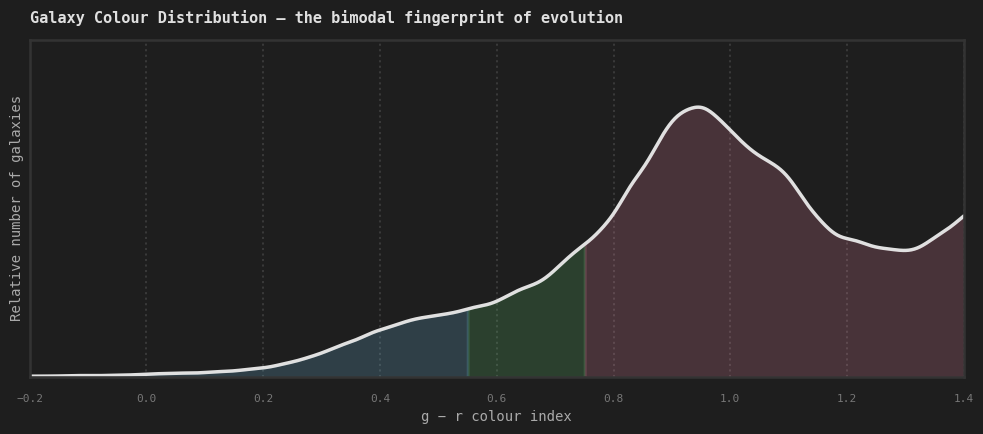

In [39]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

g_r = galaxies["g_r"].values
x_range = np.linspace(-0.2, 1.4, 1000)

# KDE
kde = gaussian_kde(g_r, bw_method=0.06)
kde_vals = kde(x_range)
kde_vals /= kde_vals.max()  # Normalise to 1 for clean y-axis

# Green Valley shading
gv_lo, gv_hi = 0.55, 0.75
gv_mask = (x_range >= gv_lo) & (x_range <= gv_hi)
ax.fill_between(x_range, 0, kde_vals / kde_vals.max(),
                where=gv_mask, color="#69db7c", alpha=0.18, zorder=1)

# Blue cloud fill
blue_mask = x_range < gv_lo
ax.fill_between(x_range, 0, kde_vals,
                where=blue_mask, color="#74c7ec", alpha=0.20, zorder=1)

# Red sequence fill
red_mask = x_range > gv_hi
ax.fill_between(x_range, 0, kde_vals,
                where=red_mask, color="#f38ba8", alpha=0.20, zorder=1)

# KDE line
ax.plot(x_range, kde_vals, lw=2.5, color="#e0e0e0", zorder=2)

ax.set_xlim(-0.2, 1.4)
ax.set_ylim(0, 1.25)
ax.set_yticks([])
ax.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative number of galaxies", color="#aaaaaa", fontsize=10)
ax.set_title("Galaxy Colour Distribution — the bimodal fingerprint of evolution",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

Low-z sample: 46,038 galaxies (z < 0.1)


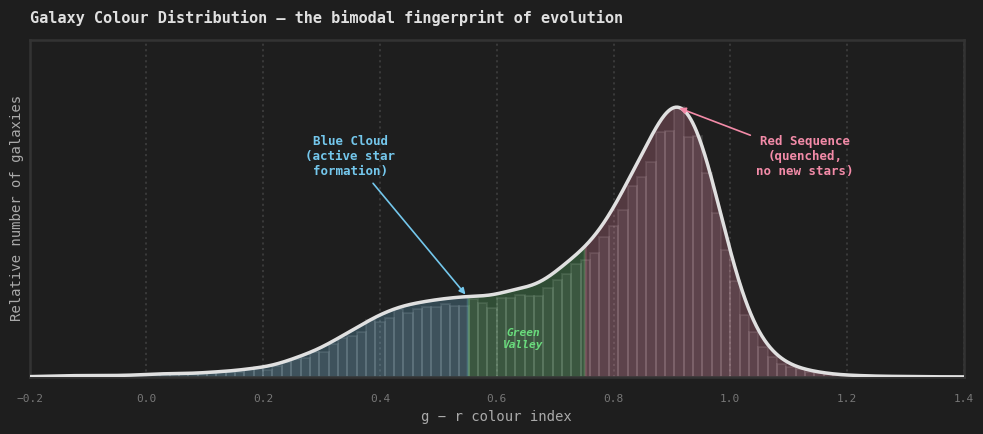

In [40]:
# Filter to z < 0.1 for a near volume-limited sample
# (higher redshift cuts off faint blue galaxies due to the telescope's flux limit,
#  artificially suppressing the blue cloud — see Part 1: Bias)
galaxies_plot = galaxies[galaxies["redshift"] < 0.1].copy()
galaxies_plot["g_r"] = galaxies_plot["g"] - galaxies_plot["r"]
galaxies_plot = galaxies_plot[
    (galaxies_plot["g_r"] > -0.2) & (galaxies_plot["g_r"] < 1.4)
]
print(f"Low-z sample: {len(galaxies_plot):,} galaxies (z < 0.1)")

g_r = galaxies_plot["g_r"].values
x_range = np.linspace(-0.2, 1.4, 1000)

kde = gaussian_kde(g_r, bw_method=0.12)
kde_vals = kde(x_range)
kde_vals = kde_vals / kde_vals.max()

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Faint histogram for texture
hist_counts, hist_edges = np.histogram(g_r, bins=100, range=(-0.2, 1.4), density=True)
hist_counts = hist_counts / hist_counts.max()
ax.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges),
       color="#aaaaaa", alpha=0.10, align="edge", zorder=1)

# Region boundaries
gv_lo, gv_hi = 0.55, 0.75

blue_mask = x_range <= gv_lo
gv_mask   = (x_range >= gv_lo) & (x_range <= gv_hi)
red_mask  = x_range >= gv_hi

ax.fill_between(x_range, 0, kde_vals, where=blue_mask,
                color="#74c7ec", alpha=0.25, zorder=2)
ax.fill_between(x_range, 0, kde_vals, where=gv_mask,
                color="#69db7c", alpha=0.25, zorder=2)
ax.fill_between(x_range, 0, kde_vals, where=red_mask,
                color="#f38ba8", alpha=0.25, zorder=2)

ax.plot(x_range, kde_vals, lw=2.5, color="#e0e0e0", zorder=3)

# Find actual peak positions from the KDE to place annotations accurately
blue_peak = x_range[np.argmax(kde_vals * (x_range < gv_lo))]
red_peak  = x_range[np.argmax(kde_vals * (x_range > gv_hi))]

ax.annotate(
    "Blue Cloud\n(active star\nformation)",
    xy=(blue_peak, kde([blue_peak])[0] / kde(x_range).max()),
    xytext=(blue_peak - 0.20, 0.75),
    color="#74c7ec", fontsize=9, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="-|>", color="#74c7ec", lw=1.2)
)
ax.annotate(
    "Red Sequence\n(quenched,\nno new stars)",
    xy=(red_peak, kde([red_peak])[0] / kde(x_range).max()),
    xytext=(red_peak + 0.22, 0.75),
    color="#f38ba8", fontsize=9, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="-|>", color="#f38ba8", lw=1.2)
)
ax.text(0.645, 0.10, "Green\nValley", color="#69db7c", fontsize=8,
        fontweight="bold", ha="center", va="bottom", style="italic")


ax.set_xlim(-0.2, 1.4)
ax.set_ylim(0, 1.25)
ax.set_yticks([])
ax.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative number of galaxies", color="#aaaaaa", fontsize=10)
ax.set_title("Galaxy Colour Distribution — the bimodal fingerprint of evolution",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

The two peaks are unmistakable. Rather than a single broad distribution, we see:

* A **Blue Cloud** centred around $g - r \approx 0.35$ — galaxies actively churning out new stars
* A **Red Sequence** centred around $g - r \approx 0.85$ — galaxies that have gone quiet
* A sparse **Green Valley** between them — galaxies currently mid-transition

The relative scarcity of Green Valley galaxies is itself a clue: it suggests the transition from blue to red happens *fast* relative to cosmic timescales. Galaxies don't linger in the middle — they pass through quickly.

</div>

Sample: 12,238 galaxies (z < 0.05)
Peaks at g-r = [0.444 0.817], heights = [0.632 1.   ]


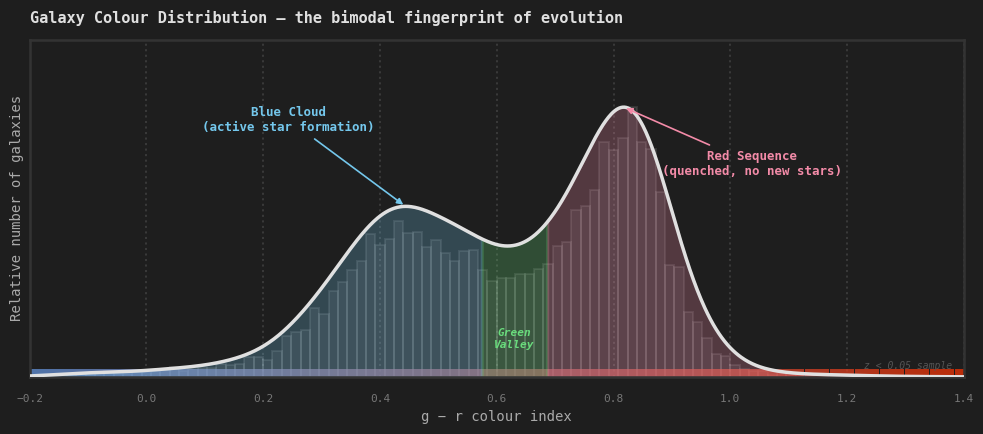

In [41]:
# Volume-limited to z < 0.05, only where blue cloud is detectable
galaxies_plot = galaxies[galaxies["redshift"] < 0.05].copy()
galaxies_plot["g_r"] = galaxies_plot["g"] - galaxies_plot["r"]
galaxies_plot = galaxies_plot[(galaxies_plot["g_r"] > -0.2) & (galaxies_plot["g_r"] < 1.4)]
print(f"Sample: {len(galaxies_plot):,} galaxies (z < 0.05)")

g_r = galaxies_plot["g_r"].values
x_range = np.linspace(-0.2, 1.4, 1000)

kde = gaussian_kde(g_r, bw_method=0.2)
kde_vals = kde(x_range)
kde_vals = kde_vals / kde_vals.max()

# Find peaks
peaks, _ = find_peaks(kde_vals, height=0.15, distance=60)
print(f"Peaks at g-r = {x_range[peaks].round(3)}, heights = {kde_vals[peaks].round(3)}")

blue_x = x_range[peaks[0]]  if len(peaks) >= 2 else 0.40
red_x  = x_range[peaks[-1]] if len(peaks) >= 1 else 0.91
blue_h = kde([blue_x])[0] / kde(x_range).max()
red_h  = kde([red_x])[0]  / kde(x_range).max()
gv_mid = (blue_x + red_x) / 2
gv_lo  = blue_x + (red_x - blue_x) * 0.35
gv_hi  = blue_x + (red_x - blue_x) * 0.65

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Faint histogram
hist_counts, hist_edges = np.histogram(g_r, bins=100, range=(-0.2, 1.4), density=True)
hist_counts = hist_counts / hist_counts.max()
ax.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges),
       color="#aaaaaa", alpha=0.10, align="edge", zorder=1)

# Fills
blue_mask = x_range <= gv_lo
gv_mask   = (x_range >= gv_lo) & (x_range <= gv_hi)
red_mask  = x_range >= gv_hi

ax.fill_between(x_range, 0, kde_vals, where=blue_mask, color="#74c7ec", alpha=0.25, zorder=2)
ax.fill_between(x_range, 0, kde_vals, where=gv_mask,   color="#69db7c", alpha=0.25, zorder=2)
ax.fill_between(x_range, 0, kde_vals, where=red_mask,  color="#f38ba8", alpha=0.25, zorder=2)
ax.plot(x_range, kde_vals, lw=2.5, color="#e0e0e0", zorder=3)

# Annotations
ax.annotate(
    "Blue Cloud\n(active star formation)",
    xy=(blue_x, blue_h),
    xytext=(blue_x - 0.20, blue_h + 0.28),
    color="#74c7ec", fontsize=9, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="-|>", color="#74c7ec", lw=1.2)
)
ax.annotate(
    "Red Sequence\n(quenched, no new stars)",
    xy=(red_x, red_h),
    xytext=(red_x + 0.22, red_h - 0.25),
    color="#f38ba8", fontsize=9, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="-|>", color="#f38ba8", lw=1.2)
)
ax.text(gv_mid, 0.10, "Green\nValley", color="#69db7c", fontsize=8,
        fontweight="bold", ha="center", va="bottom", style="italic")

# Colour gradient bar
for gx in np.linspace(-0.2, 1.4, 300):
    t = (gx + 0.2) / 1.6
    r_ch = np.clip(0.4 + 0.6 * t, 0, 1)
    g_ch = np.clip(0.6 - 0.4 * t, 0, 1)
    b_ch = np.clip(0.9 - 0.9 * t, 0, 1)
    ax.axvspan(gx, gx + 1.6/300, ymin=0, ymax=0.025,
               color=(r_ch, g_ch, b_ch), alpha=0.7, linewidth=0)

ax.set_xlim(-0.2, 1.4)
ax.set_ylim(0, 1.25)
ax.set_yticks([])
ax.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative number of galaxies", color="#aaaaaa", fontsize=10)
ax.set_title("Galaxy Colour Distribution — the bimodal fingerprint of evolution",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")
ax.text(1.38, 0.03, "z < 0.05 sample", color="#555555",
        fontsize=7, ha="right", style="italic")

plt.tight_layout()
plt.show()

---

### Plot 2 — The Colour–Magnitude Diagram

---

<div style="width: 1200px">

The colour distribution alone is striking, but it becomes even more revealing when we plot colour *against brightness*.

The **Colour–Magnitude Diagram (CMD)** places each galaxy on a 2D plane:

* **x-axis:** $r$-band magnitude — a measure of apparent brightness (brighter objects have *lower* magnitude numbers, following astronomical convention)
* **y-axis:** $g - r$ colour

In this diagram, the Blue Cloud and Red Sequence don't just appear as separate blobs — they reveal a deeper pattern: **brighter (more massive) galaxies tend to be redder**. The Red Sequence is not just a population of old galaxies; it's a population of *massive* old galaxies. This links galaxy mass to quenching history in a fundamental way.

</div>

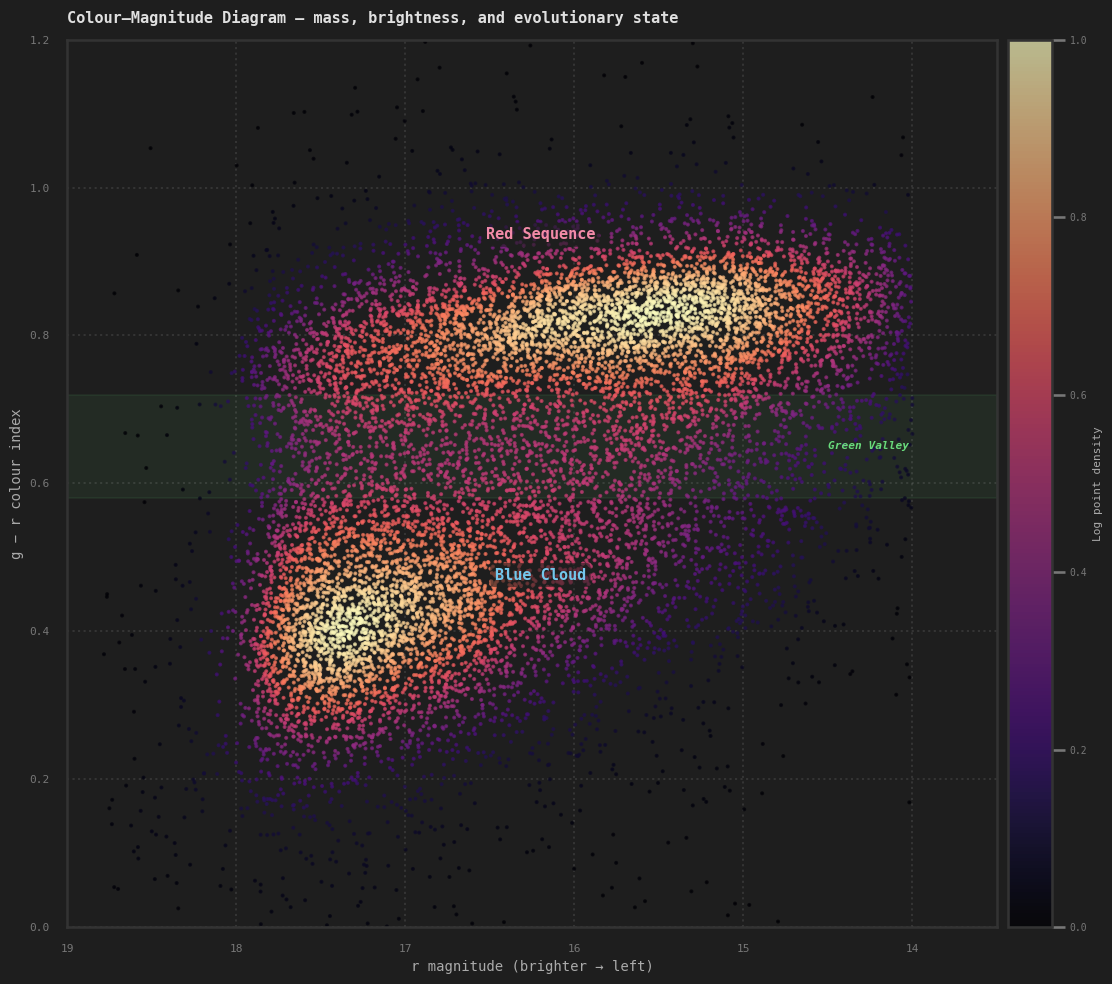

In [44]:
sample = galaxies_plot[(galaxies_plot["r"] > 14) & (galaxies_plot["r"] < 18.8)].copy()

x = sample["r"].values
y = sample["g_r"].values

# Density colouring
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
sort_idx = density.argsort()
x, y, density = x[sort_idx], y[sort_idx], density[sort_idx]

log_density = np.log1p(density)
log_density = (log_density - log_density.min()) / (log_density.max() - log_density.min())

gv_lo_cmd, gv_hi_cmd = 0.58, 0.72

fig, ax = plt.subplots(figsize=(12, 10), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

sc = ax.scatter(x, y, c=log_density, s=2, alpha=0.7,
                cmap="magma", rasterized=True)

# Green valley band
ax.axhspan(gv_lo_cmd, gv_hi_cmd, color="#69db7c", alpha=0.07, zorder=0)
ax.text(14.5, (gv_lo_cmd + gv_hi_cmd) / 2, "Green Valley",
        color="#69db7c", fontsize=8, fontweight="bold",
        style="italic", va="center", ha="left")

label_props = dict(fontsize=11, fontweight="bold", ha="center",
                   bbox=dict(boxstyle="round,pad=0.3", fc="#1e1e1e",
                             ec="none", alpha=0.6))
ax.text(16.2, 0.93, "Red Sequence", color="#f38ba8", **label_props)
ax.text(16.2, 0.47, "Blue Cloud",   color="#74c7ec", **label_props)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("Log point density", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

ax.set_xlabel("r magnitude (brighter → left)", color="#aaaaaa", fontsize=10)
ax.set_ylabel("g − r colour index", color="#aaaaaa", fontsize=10)
ax.set_title("Colour–Magnitude Diagram — mass, brightness, and evolutionary state",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.set_xlim(19, 13.5)
ax.set_ylim(0, 1.2)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.1, color="#ffffff")
for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

Several things jump out of this diagram:

* The **Red Sequence** is genuinely a *sequence* — it forms a tight, tilted ridge running diagonally. Brighter (more massive) galaxies are slightly redder, and the relationship is surprisingly tight. This regularity suggests that massive galaxies quench early and uniformly, then simply age in place.

* The **Blue Cloud** is much more scattered — star-forming galaxies span a wide range of colours, reflecting the variety of star formation rates and dust contents within them.

* The **Green Valley** (the faint horizontal band) is visibly underpopulated relative to either peak — confirming that the transition between the two populations is swift.

* The colour bar (density) reveals where galaxies pile up. The densest concentrations sit firmly in the Blue Cloud and along the Red Sequence ridge — not in between.

</div>

---

### What We've Learned

---

<div style="width: 1200px">

Two plots, one profound conclusion: galaxy evolution is **bimodal**. Galaxies are not scattered uniformly across all possible colours — they cluster into two distinct families, separated by a sparsely populated transition zone.

This is the observational foundation for everything that follows:

* Something causes star formation to **switch off** — and to do so quickly enough that few galaxies are caught mid-transition
* This process is linked to **galaxy mass**: more massive galaxies are more likely to have quenched
* The Green Valley galaxies are the most scientifically interesting — they are the ones actively undergoing transformation right now

In the next notebook, we move beyond colour and begin examining **size and structure** — asking whether a galaxy's shape and morphology tell the same evolutionary story as its colour.

</div>